<a href="https://colab.research.google.com/github/ManJ-PC/Natural-Language-Processing/blob/main/ATTRACT_XAI_HO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

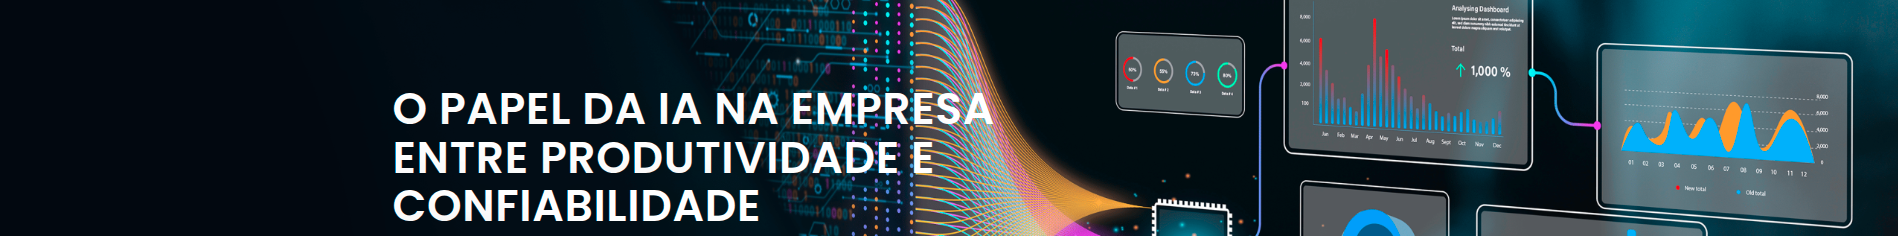

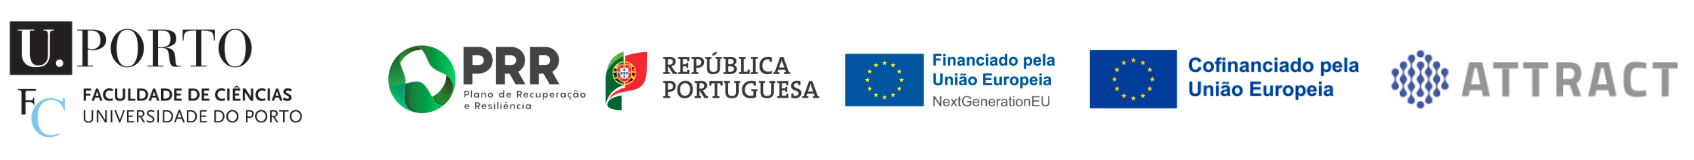

# **Explainable AI (XAI)**

## **Exploring LIME and SHAP for Explanability**

In this tutorial, we will explore the LIME and SHAP techniques to provide some explanations to the outcomes of our machine learning models. We will focus on two popular Python packages, [lime](https://pypi.org/project/lime/) and [shap](https://pypi.org/project/shap/), and consider the [Adult dataset](https://shap.readthedocs.io/en/latest/generated/shap.datasets.adult.html) provided within the `shap` package.

In particular, the Adult dataset is a binary classification problem that aims to determine whether a certain individual makes more that 50K (1/True) or not (0/False).

Make sure to install both `lime` and `shap` packages in your virtual environment before trying to replicate the code below.

*Let's get started!*

In [1]:
%pip install lime seaborn scikit-learn matplotlib pandas numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e2e7cf94abcf9adccf6a42e8c8254a8fc2d27eeefd18537a4cd0e7cbe095eae7
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


## **Exploring LIME**

There are several Python libraries that we can use to extract explanations from our machine learning models. In this example, we'll use the `lime` Python Library to build an **explainer object** and use it to get local explanations for our samples of interest.

We'll use XGBoost model and generate explanations for our **sample 20** to understand more details regarding its outcome. First, we need to build a XGBoost model to make predictions from our data:

In [2]:
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import xgboost
import numpy as np

# Load adult dataset
X, y = shap.datasets.adult()

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

# Initialize XGBoost model
xgb_model = xgboost.XGBClassifier(random_state=42)

# Fit the model with training data
xgb_model.fit(X_train, y_train)

# Generate predicitons for the test set
y_pred = xgb_model.predict(X_test)

# Calculating ROC-AUC of predictions
roc_auc_val = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
print("ROC-AUC of predictions: {}".format(roc_auc_val))

ROC-AUC of predictions: 0.9250042981774006


Now we can create an `explainer` object for LIME to explain some individual predictions. In the following example, we will consider sample 20:

In [5]:
X

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,4,12.0,2,13,5,4,0,0.0,0.0,38.0,39
32557,40.0,4,9.0,2,7,4,4,1,0.0,0.0,40.0,39
32558,58.0,4,9.0,6,1,1,4,0,0.0,0.0,40.0,39
32559,22.0,4,9.0,4,1,3,4,1,0.0,0.0,20.0,39


In [3]:
import lime.lime_tabular

# Create explainer objects
explainer = lime.lime_tabular.LimeTabularExplainer(
    np.array(X_train), feature_names=X_train.columns,
    class_names=['Lower income','Higher income'], verbose=True)


In [4]:
# Visualize sample 20
print(X_test.iloc[20])

# Visualizing explanation by LIME
print('Actual label of sample 20: {}'.format(y_test[20]))
print('Prediction for sample 20: {}'.format(y_pred[20]))
exp = explainer.explain_instance(data_row = X_test.iloc[20],
                                    predict_fn = xgb_model.predict_proba,
                                    num_features = 5)
exp.show_in_notebook(show_table=True)

Age               45.0
Workclass          4.0
Education-Num      3.0
Marital Status     2.0
Occupation         7.0
Relationship       4.0
Race               4.0
Sex                1.0
Capital Gain       0.0
Capital Loss       0.0
Hours per week    40.0
Country            0.0
Name: 32413, dtype: float64
Actual label of sample 20: False
Prediction for sample 20: 0
Intercept 0.8645098906117612
Prediction_local [0.09023047]
Right: 0.02743655


/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

**Let's examine the output:**

- At the top we present the **actual and predicted labels** for sample 20
- Then, we get the Intercept of the linear model created by LIME ("Intercept"), followed by the local prediction from our linear model ("Prediction_local") and the actual prediction from our black-box model ("Right"). This is the result of setting `verbose = True`.
- It seems that the predition generated by the linear model and the result generated by out model are in agreement.

**LIME also outputs three visual outputs that contribute to the explanation:**

- The left most section displays the prediction probabilities for each class, as the original black-box model predicted: 0.97 for "Lower Income" and 0.03 for "Higher Income", hence, the example was classified as "Lower Income".
- The middle section returns the 5 most important features. For a binary classification task, it shows 2 colors (orange/blue). Features in orange support class 1 ("Higher Income") and features in blue support class 0 ("Lower Income"). The plot therefore reveals the local contribution of features in predicting the outcome. The **Capital Gain**, **Hours per week**, and **Education-Num** contribute to pushing the prediction of towards "Low Income", while **Relationship** and **Age** push the prediction towards the other class. For LIME to provide more intuitive explanations, the numerical values are being discretized into several groups, that is why in the middle chart the features are provided along side a certain range. This is the default in LIME, and it can be changed by setting the variable `dicretize_continuous` to `False`.
- The right most section shows the values of each feature for the specific data point we're considering (sample 20). They are also sorted by their effect on the prediction, where the feature that impacted the most is at the top.

We can additional get the $R^2$ of our linear local model, which helps us decide whether to trust a certain explanation or not:


In [6]:
exp.score

0.5868582724798059

And we can access the weight given to each feature in the model using:

In [7]:
exp.as_list(label=1)

[('Capital Gain <= 0.00', -0.7104823403077319),
 ('Hours per week <= 40.00', -0.09498141784243583),
 ('Education-Num <= 9.00', -0.06791064171934481),
 ('37.00 < Age <= 48.00', 0.05332512746080408),
 ('Marital Status <= 2.00', 0.04576985210372686)]

Summing up the weights and the intercept will result in the local prediction generated by LIME:

In [8]:
# Note: here, coefficients are already multiplied by feature values
exp.intercept[1] + sum([weight[1] for weight in exp.local_exp[1]])

np.float64(0.09023047030677955)

In [13]:
xgb_model.predict_proba

<bound method XGBClassifier.predict_proba of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)>

In [9]:
raw_data, target = shap.datasets.adult(display=True)

In [15]:
X

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,4,12.0,2,13,5,4,0,0.0,0.0,38.0,39
32557,40.0,4,9.0,2,7,4,4,1,0.0,0.0,40.0,39
32558,58.0,4,9.0,6,1,1,4,0,0.0,0.0,40.0,39
32559,22.0,4,9.0,4,1,3,4,1,0.0,0.0,20.0,39


In [10]:
raw_data # comparar e atribuir a legenda as labels

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,Private,12.0,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0.0,38.0,United-States
32557,40.0,Private,9.0,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40.0,United-States
32558,58.0,Private,9.0,Widowed,Adm-clerical,Unmarried,White,Female,0.0,0.0,40.0,United-States
32559,22.0,Private,9.0,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,20.0,United-States


## **Exploring SHAP**

A machine learning model's prediction, $f(x)$ can be represented as the sum of its computed SHAP values, plus a fixed base value:

$f(x)= \text{base value} + sum(\text{SHAP values})$

For classification models, the `base value` is the average of all predictions in the training set.


### **Local Interpretability Plots**

Explaining predictions for individual data points refers to **local interpretability**. SHAP values are used to explain individual model predictions, telling us how a certain feature value has contributed to the model prediction. Specifically, SHAP can let us know whether the feature value increases or decreases the probability of a positive prediction. To evaluate the effect of specific feature values in explaining a prediction, we can make use of **Waterfall Plots** and **Force Plots**.


#### **Waterfall Plots**

Waterfall plots are comphreensive explanations of the prediction of a single data point. Each feature value in the given data point has an associated SHAP value that translates its contribution to the prediction $f(x)$, in comparison to the average prediction (*base value* or $E[f(x)]$). The waterfall structure clearly showcases the additive nature of the SHAP values, where positive values contribute to the increase of the probability, pushing towards class > 50K, whereas negative SHAP values are interpreted as decreasing the probability, pushing towards the other class (< 50k).


There are different methods to approximate feature importance that are available in the SHAP library, such as `shap.LinearExplainer()`, `shap.KernelExplainer()`, `shap.TreeExplainer()`, and `shap.DeepExplainer()`. We can use `shap.TreeExplainer()` in the case of tree-based methods such as Random Forest and XGBoost. Let's build an explainer object using the trained model and then extract the Shapley values:

In [12]:
explainer = shap.TreeExplainer(
    xgb_model,
    data=X_train,  # important!
    feature_perturbation="interventional",
    model_output="probability"
)

# Extract SHAP values from the explainer object
shap_values = explainer.shap_values(X_test)

100%|===================| 9746/9769 [00:52<00:00]       

We can now investigate how features contributed to the correct or wrong prediction for a data point. We're going to use **sample 20** again. We can use `shap.plots._waterfall.waterfall_legacy()` and extract the expected values of the input features. Recall that $f(x)$ is the predicted value given $x$, and $E[f(x)]$ is the expected value of the target feature, that is, the average of all predictions in the training set, `mean(model.predict(X_train))`. This plot shows us how much a single feature affected the prediction.

In [16]:
# Extract expected values
expected_value = explainer.expected_value
print("Expected Value: ", expected_value)

Expected Value:  0.24202866028238695


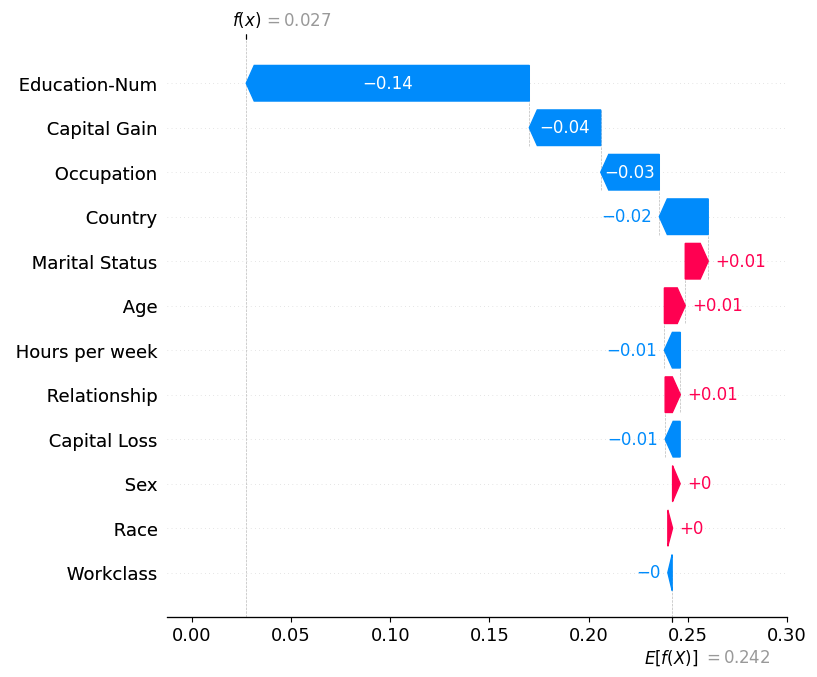

In [17]:
# Generate waterfall plot for observation 20
shap.plots._waterfall.waterfall_legacy(expected_value,
                                       shap_values[20],
                                       features=X_test.iloc[20,:],
                                       feature_names=X.columns,
                                       max_display=20,
                                       show=True)

Examining the output, we can see that for this sample **Education-Num** is the greatest contributor towards the prediction of < 50K, i.e. (0). In turn, **Relationship** contributes the most to pushing the prediction towards the other class (> 50K).

In [18]:
# f(x) corresponds to base_value + \sum over all shap values
print(f'f(x) = {expected_value + sum(shap_values[20])}')

f(x) = 0.02743655802293571


#### **Force Plots**

In alternative to waterfall plots, force plots summarize the information in a more condensed format:

In [19]:
# Print the JS visualization code to the notebook
shap.initjs()

# Produce force plot
shap.force_plot(explainer.expected_value, shap_values[20], X_test.iloc[20,:])

Now, features values that push the models towards > 50K appear on the left side in red, whereas features that push towards the < 50K appear in the right side in blue. The values of each feature are shown next to them and the larger the SHAP value (in module), the larger the arrow that represents it.

### **Global Interpretability Plots**

Although SHAP is a local explanation technique, it can also be extended to a global explainable technique by aggregating the SHAP values for a set of individual predictions. To assess global interpretability we can explore **feature importance plots**, **summary or beeswarm plots** and **dependence plots**.

### **Feature Importance Plots**

The simplest way to obtain a global explanation of a model is to determine and visualize the **mean absolute SHAP values** for each feature, which we call a feature importance plot. In this plot, each feature is associated with its average contribution towards the outcome of the model. In such a way, features with higher mean absolute SHAP values are more influencial to the model's predictions.

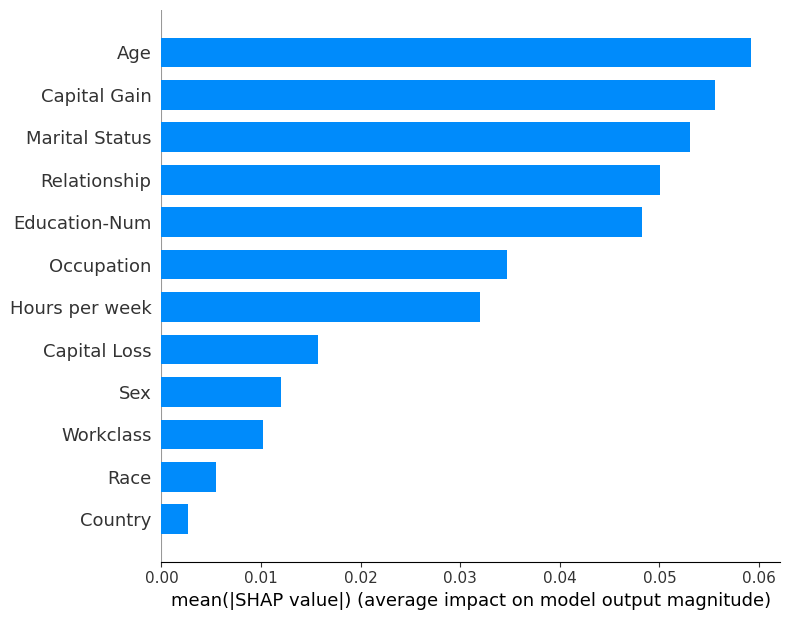

In [20]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

Feature importance plots are typically represented as bar plots ranking the features according to their impact on the model's predictions. For this model, we see that **Relationship** is the most influencial feature and **Country** is the least influencial.

#### **Summary or Beeswarm Plots**

Summary or Beeswarm plots are able to "zoom in" into the above feature importance plots, providing a global understanding of how each features affect the model's predictions by presenting a much richer information of SHAP values that reveals both the relative importance of feature, but also their relationship (i.e., "direction") with the predicted outcome.

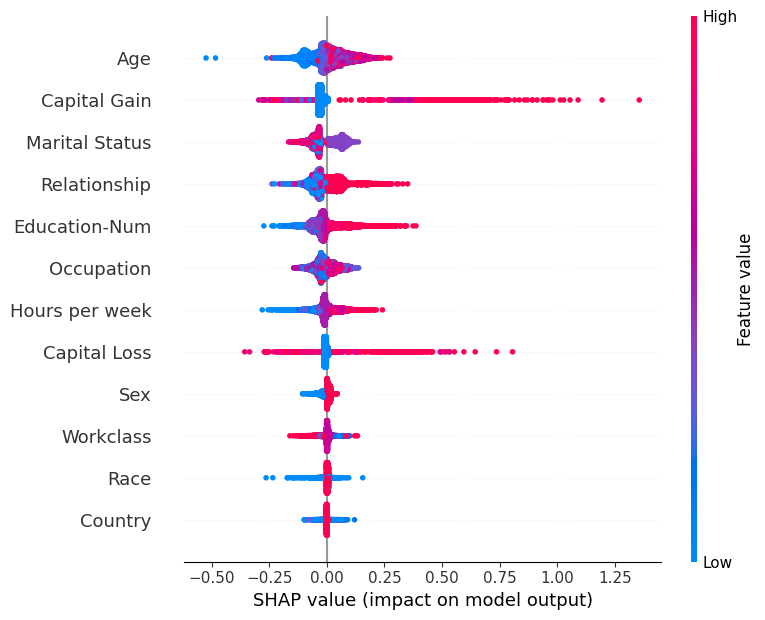

In [21]:
shap.summary_plot(shap_values, X_test)

In comparison to the previous plot, we can see that the overall tendency of feature influence is kept, since the features stay ranked in the same order, according to their mean absolute SHAP. However, there is more information about how the feature values relate to the model's output. In a beeswarm, for each feature, each instance in the dataset appears as it's own point. The points are displayed along the x-axis according to their SHAP value and in places where there is a high density of SHAP values, the points appear stacked vertically.

Now, the color (red and blue) corresponds to higher or low values of the feature: in this case, **it has nothing to do with the SHAP values**. However, by examining the color distribution horizontally along the x-axis provides some insights on the relationship between high or low values and the corresponding SHAP values. For instance, for **Relationship**, higher values *generally* (there are exceptions) have positive SHAP values, which indicates that they contribute positively to the log-odd (increase of the log-odds, which means contributing to the > 50K class in this example). On contrary, lower values of **Age** contribute more to pushing the prediction towards < 50K. Also, it is interesting to note that **Age** has more influence overall than **Capital Gain** (consider the feature importance plot). However, for those samples where Capital Gain has an influence, it has a large influence, more than Age. In other words, Capital Gain effects a few predictions by a large amount, while Age effects generally all predictions by a smaller amount.

## **Bibliography**
- To consolidate the concepts discussed herein, please refer to the following:
    - Ribeiro, M. T. et al. [Why should I trust you? Explaining the predictions of any classifier](https://www.kdd.org/kdd2016/papers/files/rfp0573-ribeiroA.pdf). In Proceedings of the 22nd ACM SIGKDD international conference on knowledge discovery and data mining (pp. 1135-1144), 2016.
    - Scott, M., & Su-In, L. (2017). [A unified approach to interpreting model predictions](https://proceedings.neurips.cc/paper_files/paper/2017/file/8a20a8621978632d76c43dfd28b67767-Paper.pdf). Advances in neural information processing systems, 30, 4765-4774.
    